# Fase 4 — Dashboards e Visualizações Analíticas (Plotly)

**Disciplina:** Métodos Quantitativos (TADS 2026.1)
**Objetivo:** sintetizar as características da base de dados e os resultados do modelo de predição de risco de AVC em painéis interativos, consolidando os insights de negócio das fases anteriores em gráficos prontos para tomada de decisão.

Este notebook é o entregável da **Fase 4** do projeto e é independente da aplicação web (Fase 5): todos os gráficos são gerados diretamente a partir dos dados brutos (`data/raw`), dos artefatos de treino (`models/`) e dos relatórios de métricas (`reports/`) com **Plotly**.

> *Os gráficos abaixo estão salvos como imagens estáticas (PNG) para garantir que o notebook abra rapidamente em qualquer editor. A versão totalmente interativa do painel consolidado está em `reports/dashboard_fase4.html`.*

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.templates.default = "plotly_white"
pio.renderers.default = "png"  # imagens estáticas via kaleido: notebook leve e abre em qualquer editor (VS Code, GitHub, nbviewer) sem depender de extensões de renderer JS
PALETTE = {0: "#94a3b8", 1: "#d97757"}  # cinza neutro (sem AVC) vs terracota (AVC)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = ROOT / "data" / "raw" / "healthcare-dataset-stroke-data.csv"
METRICS_PATH = ROOT / "reports" / "metrics.json"
ROC_PATH = ROOT / "reports" / "roc_curve_test.csv"
MODEL_PATH = ROOT / "models" / "stroke_risk_model.joblib"
DASHBOARD_OUT = ROOT / "reports" / "dashboard_fase4.html"

df = pd.read_csv(RAW_PATH)
with open(METRICS_PATH, "r", encoding="utf-8") as f:
    metrics = json.load(f)
roc_df = pd.read_csv(ROC_PATH)
artifact = joblib.load(MODEL_PATH)

df.shape, df["stroke"].mean()

((5110, 12), np.float64(0.0487279843444227))

## 1. Perfil Geral da Base de Dados

A base possui **5.110 registros**. Antes de qualquer visualização, resumimos volume, prevalência do desfecho, nulos e possíveis outliers — pontos já levantados na Fase 1 (EDA) e que justificam as escolhas de pré-processamento da Fase 2.

In [2]:
total_registros = len(df)
taxa_avc = df["stroke"].mean() * 100
nulos_bmi = df["bmi"].isna().sum()

perfil = pd.DataFrame({
    "Indicador": [
        "Total de registros",
        "Casos de AVC (classe 1)",
        "Prevalência de AVC",
        "Valores nulos em BMI",
        "Categoria 'Unknown' em smoking_status",
    ],
    "Valor": [
        f"{total_registros:,}",
        f"{int(df['stroke'].sum())}",
        f"{taxa_avc:.2f}%",
        f"{nulos_bmi} ({nulos_bmi/total_registros:.1%})",
        f"{(df['smoking_status'] == 'Unknown').sum()} ({(df['smoking_status'] == 'Unknown').mean():.1%})",
    ],
})
perfil

,Indicador,Valor
0,Total de registros,"5,110"
1,Casos de AVC (classe 1),249
2,Prevalência de AVC,4.87%
3,Valores nulos em BMI,201 (3.9%)
4,Categoria 'Unknown' em smoking_status,1544 (30.2%)


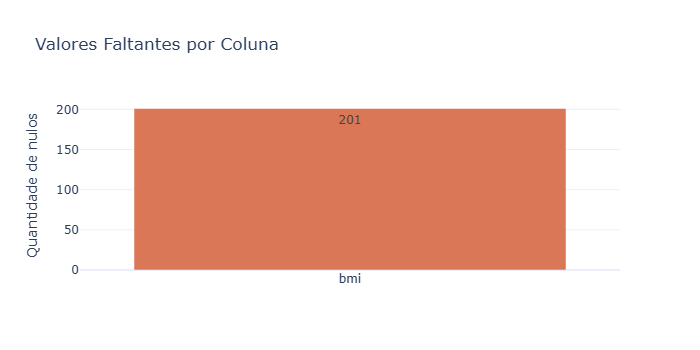

In [3]:
fig_nulos = px.bar(
    df.isna().sum().rename("nulos").reset_index().rename(columns={"index": "coluna"}).query("nulos > 0"),
    x="coluna", y="nulos", text="nulos", title="Valores Faltantes por Coluna",
    color_discrete_sequence=[PALETTE[1]],
)
fig_nulos.update_layout(height=350, yaxis_title="Quantidade de nulos", xaxis_title="")
fig_nulos.show()

## 2. Distribuições Univariadas e Outliers

Boxplots evidenciam a dispersão e os outliers das três variáveis numéricas centrais (idade, glicemia média e IMC), sem segmentação pelo desfecho.

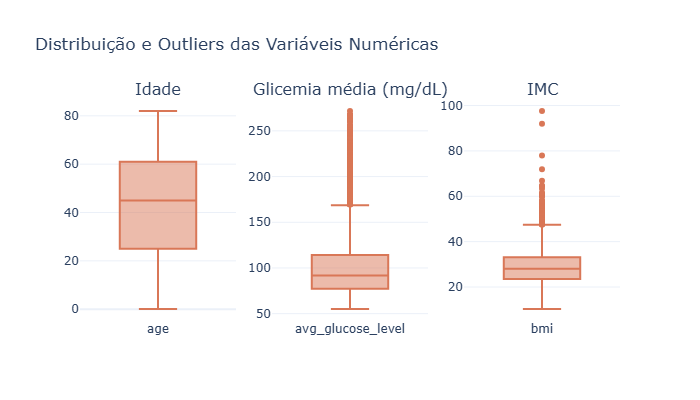

In [4]:
fig_outliers = make_subplots(rows=1, cols=3, subplot_titles=("Idade", "Glicemia média (mg/dL)", "IMC"))
for i, col in enumerate(["age", "avg_glucose_level", "bmi"], start=1):
    fig_outliers.add_trace(
        go.Box(y=df[col], name=col, marker_color=PALETTE[1], boxpoints="outliers"),
        row=1, col=i,
    )
fig_outliers.update_layout(height=400, showlegend=False, title="Distribuição e Outliers das Variáveis Numéricas")
fig_outliers.show()

In [5]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_summary = pd.DataFrame({
    "Variável": ["age", "avg_glucose_level", "bmi"],
    "Outliers (regra IQR)": [iqr_outliers(df[c].dropna()) for c in ["age", "avg_glucose_level", "bmi"]],
})
outlier_summary

,Variável,Outliers (regra IQR)
0,age,0
1,avg_glucose_level,627
2,bmi,110


## 3. Distribuição por Ocorrência de AVC (Análise Bivariada — Numéricas)

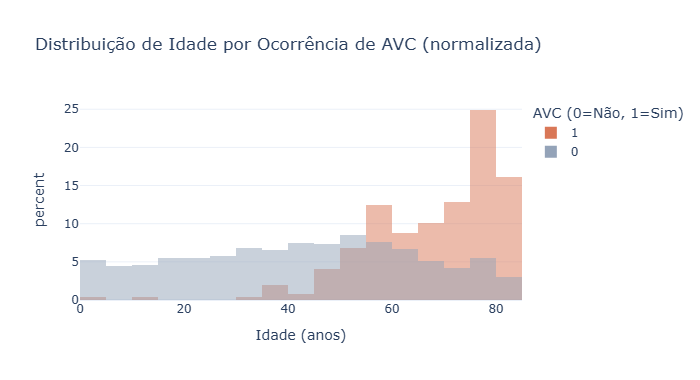

In [6]:
fig_age = px.histogram(
    df, x="age", color="stroke", nbins=40, barmode="overlay", histnorm="percent",
    color_discrete_map=PALETTE,
    labels={"age": "Idade (anos)", "stroke": "AVC"},
    title="Distribuição de Idade por Ocorrência de AVC (normalizada)",
)
fig_age.update_layout(height=380, legend_title="AVC (0=Não, 1=Sim)")
fig_age.show()

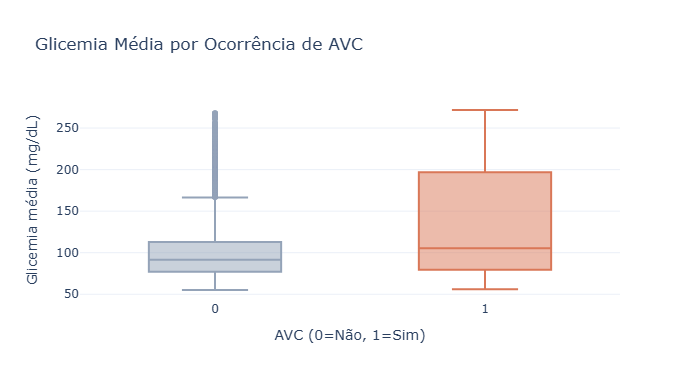

In [7]:
fig_glu = px.box(
    df, x="stroke", y="avg_glucose_level", color="stroke", color_discrete_map=PALETTE,
    labels={"stroke": "AVC (0=Não, 1=Sim)", "avg_glucose_level": "Glicemia média (mg/dL)"},
    title="Glicemia Média por Ocorrência de AVC",
)
fig_glu.update_layout(height=380, showlegend=False)
fig_glu.show()

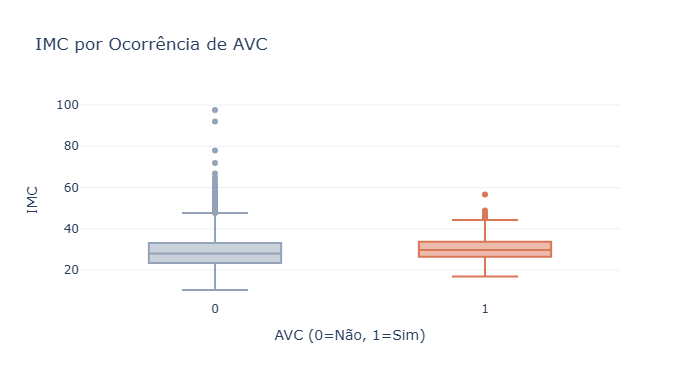

In [8]:
fig_bmi = px.box(
    df, x="stroke", y="bmi", color="stroke", color_discrete_map=PALETTE,
    labels={"stroke": "AVC (0=Não, 1=Sim)", "bmi": "IMC"},
    title="IMC por Ocorrência de AVC",
)
fig_bmi.update_layout(height=380, showlegend=False)
fig_bmi.show()

## 4. Taxa de AVC por Variáveis Categóricas e Faixas Clínicas

Aplicamos as mesmas faixas (`age_group`, `glucose_group`) definidas em `src/pipeline.py` para manter consistência com o modelo em produção, e calculamos a **taxa de AVC (%)** — mais informativa que a contagem bruta dada a forte desbalanceamento das classes.

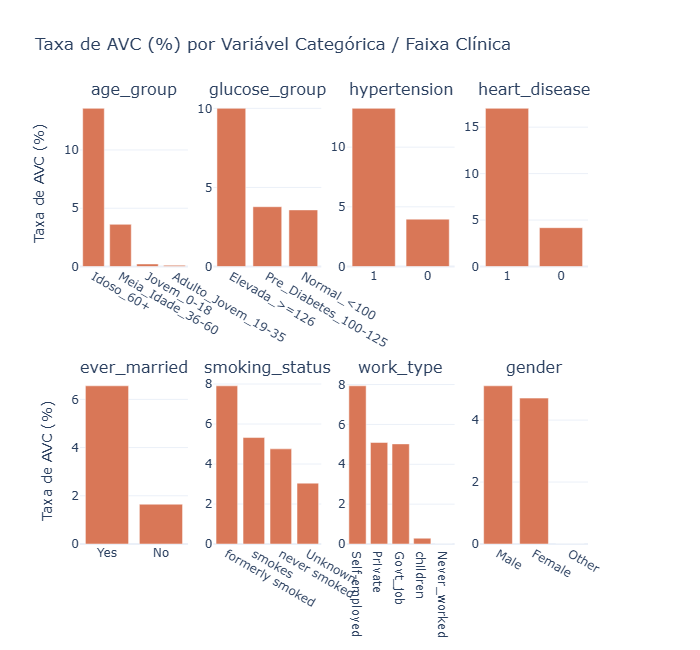

In [9]:
df_bin = df.copy()
df_bin["age_group"] = pd.cut(
    df_bin["age"], bins=[-np.inf, 18, 35, 60, np.inf],
    labels=["Jovem_0-18", "Adulto_Jovem_19-35", "Meia_Idade_36-60", "Idoso_60+"],
)
df_bin["glucose_group"] = pd.cut(
    df_bin["avg_glucose_level"], bins=[-np.inf, 100, 125, np.inf],
    labels=["Normal_<100", "Pre_Diabetes_100-125", "Elevada_>=126"],
)

cat_vars = ["age_group", "glucose_group", "hypertension", "heart_disease", "ever_married", "smoking_status", "work_type", "gender"]

fig_cat = make_subplots(rows=2, cols=4, subplot_titles=cat_vars)
for i, col in enumerate(cat_vars):
    rate = (df_bin.groupby(col, observed=True)["stroke"].mean() * 100).sort_values(ascending=False)
    r, c = divmod(i, 4)
    fig_cat.add_trace(
        go.Bar(x=rate.index.astype(str), y=rate.values, marker_color=PALETTE[1], showlegend=False),
        row=r + 1, col=c + 1,
    )
fig_cat.update_layout(height=650, title="Taxa de AVC (%) por Variável Categórica / Faixa Clínica")
fig_cat.update_yaxes(title_text="Taxa de AVC (%)", col=1)
fig_cat.show()

## 5. Correlação entre Variáveis Numéricas

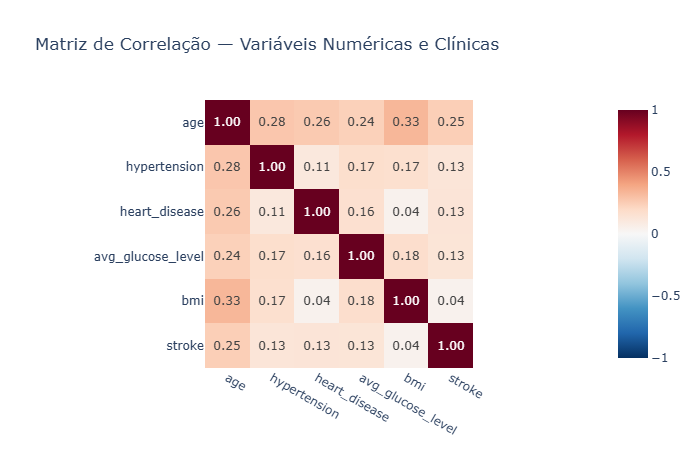

In [10]:
corr_cols = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "stroke"]
corr = df[corr_cols].corr()

fig_corr = px.imshow(
    corr, text_auto=".2f", color_continuous_scale="RdBu_r", zmin=-1, zmax=1,
    title="Matriz de Correlação — Variáveis Numéricas e Clínicas",
)
fig_corr.update_layout(height=450)
fig_corr.show()

## 6. Desempenho do Modelo — Validação vs. Teste

Métricas oficiais salvas em `reports/metrics.json` pelo script `src/train.py` (Fase 3). O limiar de decisão (`threshold`) foi calibrado na validação para maximizar o F1-Score e depois congelado para a avaliação final no teste.

In [11]:
metric_names = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
comparativo = pd.DataFrame({
    "Métrica": metric_names,
    "Validação": [metrics["validation"][m] for m in metric_names],
    "Teste": [metrics["test"][m] for m in metric_names],
})
comparativo

,Métrica,Validação,Teste
0,accuracy,0.857143,0.866928
1,precision,0.180000,0.205479
2,recall,0.540000,0.600000
3,f1_score,0.270000,0.306122
4,roc_auc,0.826749,0.840885


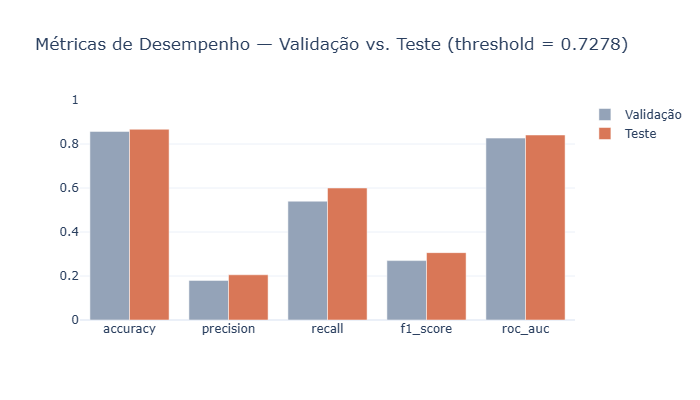

In [12]:
fig_metrics = go.Figure()
fig_metrics.add_trace(go.Bar(name="Validação", x=comparativo["Métrica"], y=comparativo["Validação"], marker_color="#94a3b8"))
fig_metrics.add_trace(go.Bar(name="Teste", x=comparativo["Métrica"], y=comparativo["Teste"], marker_color="#d97757"))
fig_metrics.update_layout(
    barmode="group", height=400, yaxis_range=[0, 1],
    title=f"Métricas de Desempenho — Validação vs. Teste (threshold = {metrics['test']['threshold']:.4f})",
)
fig_metrics.show()

## 7. Curva ROC (Conjunto de Teste)

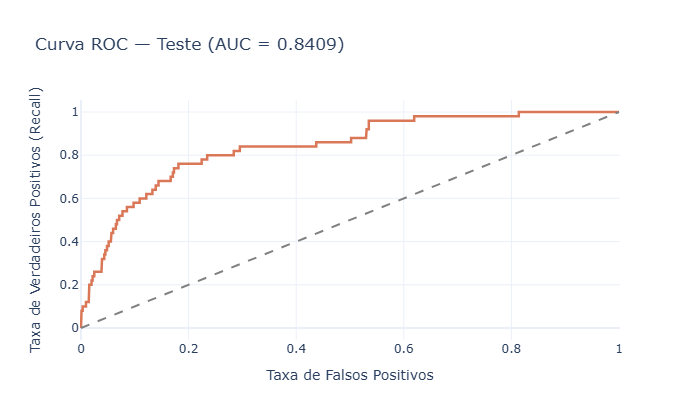

In [13]:
fig_roc = px.line(
    roc_df, x="false_positive_rate", y="true_positive_rate",
    labels={"false_positive_rate": "Taxa de Falsos Positivos", "true_positive_rate": "Taxa de Verdadeiros Positivos (Recall)"},
    title=f"Curva ROC — Teste (AUC = {metrics['test']['roc_auc']:.4f})",
)
fig_roc.add_shape(type="line", line=dict(dash="dash", color="gray"), x0=0, y0=0, x1=1, y1=1)
fig_roc.update_traces(line_color="#d97757", line_width=2.5)
fig_roc.update_layout(height=420)
fig_roc.show()

## 8. Matriz de Confusão (Conjunto de Teste)

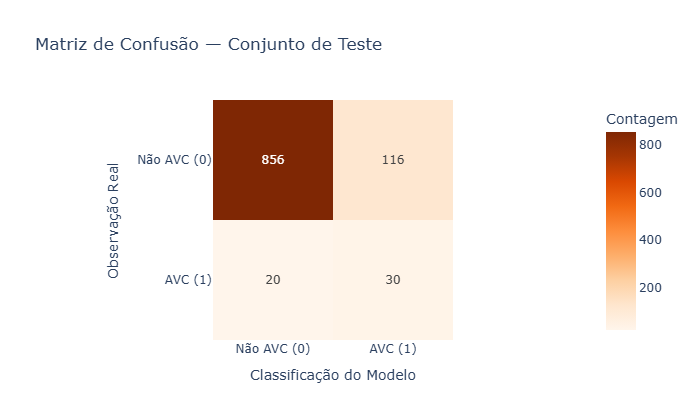

In [14]:
cm = metrics["test"]["confusion_matrix"]
cm_matrix = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])

fig_cm = px.imshow(
    cm_matrix, text_auto=True, color_continuous_scale="Oranges",
    labels=dict(x="Classificação do Modelo", y="Observação Real", color="Contagem"),
    x=["Não AVC (0)", "AVC (1)"], y=["Não AVC (0)", "AVC (1)"],
    title="Matriz de Confusão — Conjunto de Teste",
)
fig_cm.update_layout(height=420)
fig_cm.show()

## 9. Importância das Variáveis (Coeficientes da Regressão Logística)

Como o modelo final é uma `LogisticRegression` treinada sobre features já padronizadas (`StandardScaler`) e codificadas (`OneHotEncoder`), os coeficientes são diretamente comparáveis em magnitude e indicam a direção do efeito (positivo aumenta a chance de AVC, negativo reduz).

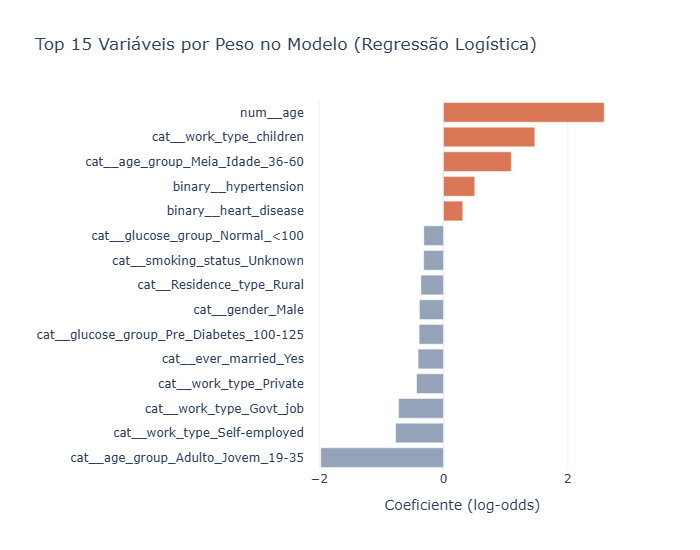

In [15]:
model = artifact["model"]
feature_names = artifact["features"]

coef_df = pd.DataFrame({"feature": feature_names, "coef": model.coef_[0]})
coef_df["abs_coef"] = coef_df["coef"].abs()
top_coef = coef_df.sort_values("abs_coef", ascending=False).head(15).sort_values("coef")

fig_coef = px.bar(
    top_coef, x="coef", y="feature", orientation="h",
    color=top_coef["coef"] > 0,
    color_discrete_map={True: "#d97757", False: "#94a3b8"},
    labels={"coef": "Coeficiente (log-odds)", "feature": "", "color": "Aumenta risco"},
    title="Top 15 Variáveis por Peso no Modelo (Regressão Logística)",
)
fig_coef.update_layout(height=550, showlegend=False)
fig_coef.show()

## 10. Painel Consolidado (Dashboard Único)

Reunimos os gráficos mais relevantes para tomada de decisão em um único painel e exportamos uma versão **HTML autônoma**, que pode ser aberta em qualquer navegador sem depender do Jupyter ou do Streamlit.

Dashboard consolidado exportado em: reports\dashboard_fase4.html


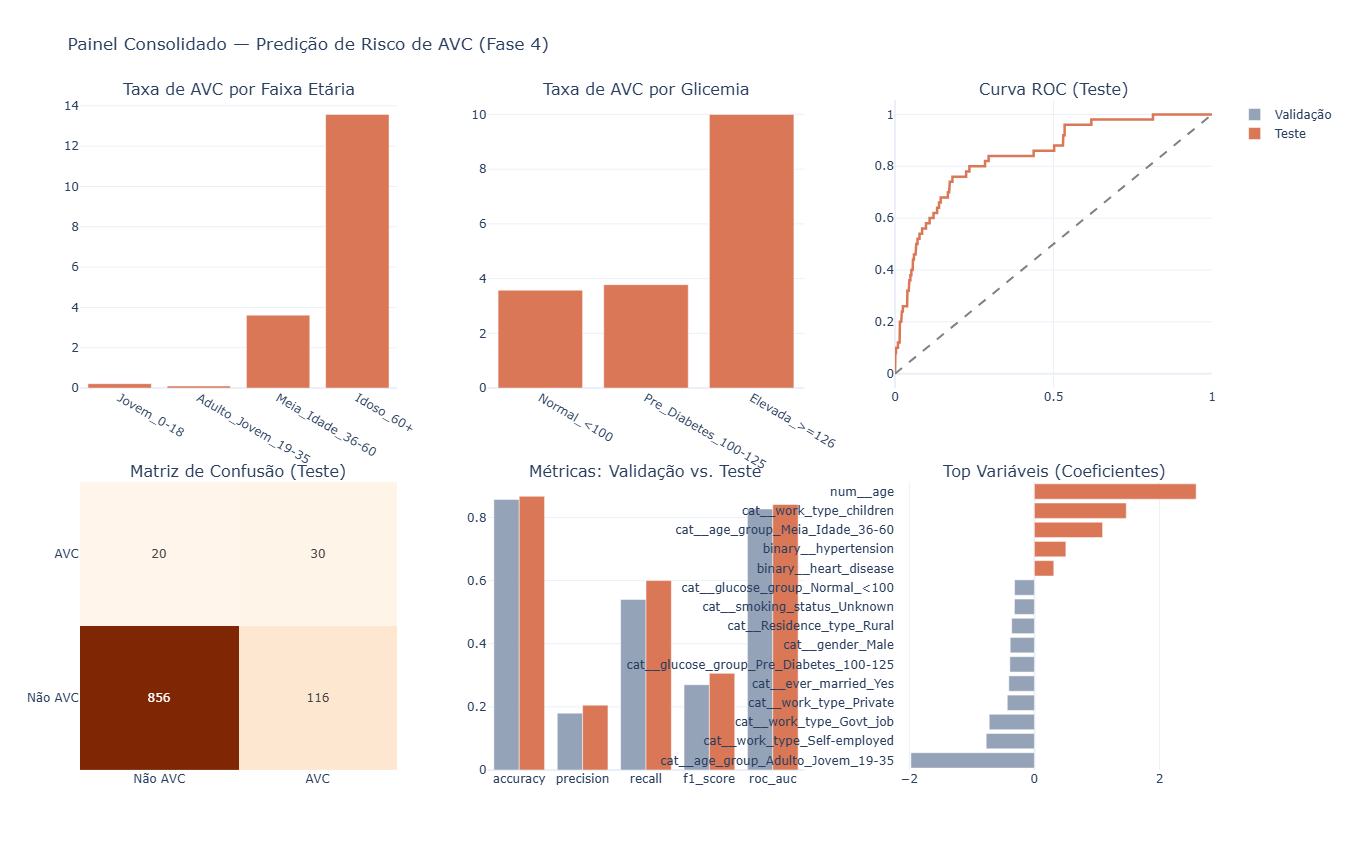

In [16]:
dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        "Taxa de AVC por Faixa Etária", "Taxa de AVC por Glicemia", "Curva ROC (Teste)",
        "Matriz de Confusão (Teste)", "Métricas: Validação vs. Teste", "Top Variáveis (Coeficientes)",
    ),
    specs=[
        [{"type": "bar"}, {"type": "bar"}, {"type": "scatter"}],
        [{"type": "heatmap"}, {"type": "bar"}, {"type": "bar"}],
    ],
    vertical_spacing=0.14, horizontal_spacing=0.08,
)

age_rate = (df_bin.groupby("age_group", observed=True)["stroke"].mean() * 100)
dashboard.add_trace(go.Bar(x=age_rate.index.astype(str), y=age_rate.values, marker_color="#d97757", showlegend=False), row=1, col=1)

glu_rate = (df_bin.groupby("glucose_group", observed=True)["stroke"].mean() * 100)
dashboard.add_trace(go.Bar(x=glu_rate.index.astype(str), y=glu_rate.values, marker_color="#d97757", showlegend=False), row=1, col=2)

dashboard.add_trace(go.Scatter(x=roc_df["false_positive_rate"], y=roc_df["true_positive_rate"], mode="lines", line=dict(color="#d97757", width=2.5), showlegend=False), row=1, col=3)
dashboard.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", line=dict(dash="dash", color="gray"), showlegend=False), row=1, col=3)

dashboard.add_trace(go.Heatmap(z=cm_matrix, x=["Não AVC", "AVC"], y=["Não AVC", "AVC"], colorscale="Oranges", showscale=False, text=cm_matrix, texttemplate="%{text}"), row=2, col=1)

dashboard.add_trace(go.Bar(name="Validação", x=comparativo["Métrica"], y=comparativo["Validação"], marker_color="#94a3b8", showlegend=True), row=2, col=2)
dashboard.add_trace(go.Bar(name="Teste", x=comparativo["Métrica"], y=comparativo["Teste"], marker_color="#d97757", showlegend=True), row=2, col=2)

dashboard.add_trace(go.Bar(x=top_coef["coef"], y=top_coef["feature"], orientation="h", marker_color=["#d97757" if v > 0 else "#94a3b8" for v in top_coef["coef"]], showlegend=False), row=2, col=3)

dashboard.update_layout(
    height=850, width=1350, barmode="group",
    title_text="Painel Consolidado — Predição de Risco de AVC (Fase 4)",
    template="plotly_white",
)
dashboard.write_html(str(DASHBOARD_OUT), include_plotlyjs="cdn")
print(f"Dashboard consolidado exportado em: {DASHBOARD_OUT.relative_to(ROOT)}")
dashboard.show()

## 11. Principais Insights de Negócio

- **Idade é o fator dominante:** a taxa de AVC cresce de forma acentuada a partir da faixa "Idoso 60+", confirmando o padrão já identificado na Fase 1.
- **Glicemia elevada (≥126 mg/dL) e hipertensão/cardiopatia** aumentam substancialmente a taxa de AVC, reforçando a escolha dessas faixas clínicas como features no pipeline (Fase 2).
- **Classes fortemente desbalanceadas (~4,8% de prevalência):** a matriz de confusão no teste mostra que o modelo prioriza **recall** (detectar a maioria dos casos reais de AVC) ao custo de mais falsos positivos — trade-off intencional dado o contexto clínico, onde deixar de identificar um caso de risco é mais custoso que um alarme falso.
- **ROC AUC ~0,84** indica boa capacidade de discriminação do modelo, mesmo com a baixa precisão observada no teste (esperada em cenários de forte desbalanceamento sem ajuste de custo assimétrico mais agressivo).
- **Coeficientes da Regressão Logística** confirmam idade, faixas glicêmicas elevadas e histórico clínico (hipertensão/cardiopatia) como as variáveis de maior peso positivo, alinhadas ao conhecimento médico de fatores de risco de AVC.
- O painel consolidado (`reports/dashboard_fase4.html`) resume esses achados em um único artefato interativo, pronto para apresentação a stakeholders sem dependências de ambiente Python.